# Решение ДЗ Pro: предсказание очков в баскетбольном матче

**Задание:** На базе баскетбольных матчей добиться **средней абсолютной ошибки (MAE) ≤ 17 очков** на проверочной выборке.

**Что есть в данных** (по результатам раздела «Подготовка»):
- `xTrain` shape `(52450, 5)` — числовые признаки: `'Ком. 1'`, `'Ком. 2'`, `'Минута'`, `'Секунда'`, `'ftime'`.
- `yTrain` shape `(52450,)` — целевое значение `fcount` (количество очков).
- `xBOW_text` shape `(52450, 5000)` — текстовое описание матча (`info`) в виде Bag of Words на 5000 слов.

**Стратегия решения:**
1. Скачиваем и подготавливаем данные ровно так же, как в шаблоне (Tokenizer, BoW).
2. Стандартизируем числовые признаки и нормируем целевую переменную (`StandardScaler`).
3. Делим на train/val (15% валидации).
4. Строим модель с **двумя входами** (числовой + текстовой) через Functional API — это даёт сильно меньшую ошибку, чем модель только на числах.
5. Обучаем с `LambdaCallback(on_epoch_end=...)`, который после каждой эпохи считает MAE в **исходных очках** на валидации и печатает прогресс.
6. Используем `ModelCheckpoint` для сохранения лучшей эпохи по MAE на валидации.
7. Финальная проверка через функцию `check_MAE_predict1_DubbleInput` с графиком разброса.


## 1. Импорты

In [1]:
# Работа с массивами и таблицами
import numpy as np
import pandas as pd

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import utils
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                     Input, concatenate)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LambdaCallback, ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer

# Прочее
from sklearn.preprocessing import StandardScaler
import gdown
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Подготовка данных
Полностью повторяем шаги из раздела «Подготовка»: скачиваем CSV, токенизируем колонку `info` (5000 слов), формируем `xTrain`, `yTrain`, `xBOW_text`.

In [2]:
# Загрузка из google облака
gdown.download(
    'https://storage.yandexcloud.net/aiueducation/Content/base/l10/basketball.csv',
    None, quiet=True
)

df = pd.read_csv('basketball.csv', encoding='cp1251', sep=';',
                 header=0, index_col=0)
print('Размер датафрейма:', df.shape)
df.head()


Размер датафрейма: (52450, 9)


,TOTAL,info,Ком. 1,Ком. 2,Минута,Общая минута,Секунда,fcount,ftime
0,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,0.0,1,1.0,30,81,90.0
1,"100,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,1,1.0,45,81,105.0
2,"99,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,0,81,120.0
3,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,30,81,150.0
4,"95,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,3,3.0,0,81,180.0


In [3]:
# Текстовые данные
data_text = df['info'].values
print('Длина текстового списка:', len(data_text))

# Токенизатор
maxWordsCount = 5000
sim_for_del   = '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'

tokenizer = Tokenizer(
    num_words=maxWordsCount,
    filters=sim_for_del,
    lower=True,
    split=' ',
    oov_token='unknown',
    char_level=False
)
tokenizer.fit_on_texts(data_text)


Длина текстового списка: 52450


In [4]:
# Эмбеддинг-последовательности и Bag of Words
Sequences  = tokenizer.texts_to_sequences(data_text)
xBOW_text  = tokenizer.sequences_to_matrix(Sequences)

# Числовые признаки
xTrain = np.array(df[['Ком. 1', 'Ком. 2', 'Минута', 'Секунда', 'ftime']]
                  .astype('int'))
yTrain = np.array(df['fcount'].astype('int'))

print('xTrain.shape    =', xTrain.shape)
print('yTrain.shape    =', yTrain.shape)
print('xBOW_text.shape =', xBOW_text.shape)


xTrain.shape    = (52450, 5)
yTrain.shape    = (52450,)
xBOW_text.shape = (52450, 5000)


## 3. Нормирование и train/val split

- Числовые признаки нормируем `StandardScaler`-ом (5 признаков с разными масштабами — особенно «секунды» против «минут»).
- Целевую переменную тоже нормируем — это сильно ускоряет сходимость регрессии. После предсказания обратно денормируем и считаем MAE в исходных очках.
- Текстовый BoW уже по сути в [0, 1] (бинарная матрица), его не трогаем.
- Делим на train/val маской (~15% валидации), маска одна и та же для всех трёх массивов.

In [5]:
# Скейлинг
x_scaler = StandardScaler()
xTrain_scaled = x_scaler.fit_transform(xTrain).astype(np.float32)

y_scaler = StandardScaler()
yTrain_scaled = y_scaler.fit_transform(yTrain.reshape(-1, 1)).astype(np.float32)

xBOW_text = xBOW_text.astype(np.float32)

# Маска валидации
np.random.seed(SEED)
val_mask = np.random.rand(len(xTrain)) < 0.15
print('Train:', (~val_mask).sum(), '   Val:', val_mask.sum())

x_tr_num,  x_val_num  = xTrain_scaled[~val_mask],  xTrain_scaled[val_mask]
x_tr_txt,  x_val_txt  = xBOW_text[~val_mask],      xBOW_text[val_mask]
y_tr_sc,   y_val_sc   = yTrain_scaled[~val_mask],  yTrain_scaled[val_mask]
y_tr_orig, y_val_orig = yTrain[~val_mask],         yTrain[val_mask]

NUM_DIM  = xTrain_scaled.shape[1]    # 5
TEXT_DIM = xBOW_text.shape[1]        # 5000
print('NUM_DIM =', NUM_DIM, ', TEXT_DIM =', TEXT_DIM)


Train: 44567    Val: 7883
NUM_DIM = 5 , TEXT_DIM = 5000


## 4. Модель с двумя входами (Functional API)

Архитектура:

- Ветка числового входа: `5 → BatchNorm → 32 → 32` (`relu`).
- Ветка текстового входа (BoW, 5000): `Dropout(0.3) → 256 → Dropout(0.3) → 64` (`relu`).
- Конкатенация веток → `64 → 32 → 1` (`linear`).

Текстовая ветка получает основное «насыщение» сигнала (BoW-разряд высокий), числовая — корректирует. `Dropout` на входе текстовой ветки и `BatchNormalization` на числовом входе — стандартные регуляризаторы для подобной задачи.

In [6]:
# Числовая ветка
input_num = Input(shape=(NUM_DIM,), name='num_input')
x1 = BatchNormalization()(input_num)
x1 = Dense(32, activation='relu')(x1)
x1 = Dense(32, activation='relu')(x1)

# Текстовая ветка
input_txt = Input(shape=(TEXT_DIM,), name='txt_input')
x2 = Dropout(0.3)(input_txt)
x2 = Dense(256, activation='relu')(x2)
x2 = Dropout(0.3)(x2)
x2 = Dense(64, activation='relu')(x2)

# Объединение
x = concatenate([x1, x2])
x = Dense(32, activation='relu')(x)
out = Dense(1, activation='linear')(x)

model = Model([input_num, input_txt], out)
model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ txt_input           │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 5000)      │          0 │ txt_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 5)         │         20 │ num_input[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │  1,280,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        192 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     16,448 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      3,104 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,301,109 (4.96 MB)

 Trainable params: 1,301,099 (4.96 MB)

 Non-trainable params: 10 (40.00 B)

## 5. Обучение с callback-ом по теории «Callbacks»

В шаблоне ДЗ предложен callback `on_epoch_end_custom`, который после каждой эпохи вызывает `check_MAE_predict1_DubbleInput`. Мы делаем то же самое через `LambdaCallback(on_epoch_end=...)`:

1. Делаем `predict` модели на валидации, обратно денормируем `y_scaler.inverse_transform(...)`.
2. Считаем MAE в **очках** и печатаем — это и есть наш целевой показатель.
3. Сохраняем историю в список, чтобы потом нарисовать график.
4. Параллельно `ModelCheckpoint` сохраняет веса лучшей эпохи по `val_loss` — после обучения загрузим именно их.

In [7]:
# История MAE в очках (для графика)
mae_pts_history = []

def on_epoch_end_callback(epoch, logs):
    pred_sc = model.predict([x_val_num, x_val_txt], verbose=0)
    pred_pts = y_scaler.inverse_transform(pred_sc).ravel()
    mae_pts = float(np.mean(np.abs(pred_pts - y_val_orig)))
    mae_pts_history.append(mae_pts)
    star = '  ★ цель достигнута' if mae_pts <= 17.0 else ''
    print(f'  Эпоха {epoch+1:3d} | '
          f'loss={logs.get("loss"):.4f}  val_loss={logs.get("val_loss"):.4f}  | '
          f'MAE val (очки) = {mae_pts:6.3f}{star}')

mae_callback = LambdaCallback(on_epoch_end=on_epoch_end_callback)

# Чекпоинт лучшей модели
checkpoint = ModelCheckpoint(
    'best_model.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=0,
)


In [8]:
history = model.fit(
    [x_tr_num, x_tr_txt], y_tr_sc,
    validation_data=([x_val_num, x_val_txt], y_val_sc),
    epochs=50,
    batch_size=512,
    verbose=0,
    callbacks=[mae_callback, checkpoint],
)

# Загружаем веса лучшей эпохи
model.load_weights('best_model.weights.h5')

# Финальная MAE на валидации с лучшими весами
pred_sc  = model.predict([x_val_num, x_val_txt], verbose=0)
pred_pts = y_scaler.inverse_transform(pred_sc).ravel()
final_mae = float(np.mean(np.abs(pred_pts - y_val_orig)))
print(f'\nЛучшая модель — MAE на валидации: {final_mae:.3f} очков')


  Эпоха   1 | loss=0.3121  val_loss=0.0397  | MAE val (очки) =  3.057  ★ цель достигнута
  Эпоха   2 | loss=0.0811  val_loss=0.0224  | MAE val (очки) =  2.952  ★ цель достигнута
  Эпоха   3 | loss=0.0571  val_loss=0.0167  | MAE val (очки) =  2.556  ★ цель достигнута
  Эпоха   4 | loss=0.0497  val_loss=0.0148  | MAE val (очки) =  2.329  ★ цель достигнута
  Эпоха   5 | loss=0.0424  val_loss=0.0173  | MAE val (очки) =  2.614  ★ цель достигнута
  Эпоха   6 | loss=0.0388  val_loss=0.0157  | MAE val (очки) =  2.407  ★ цель достигнута
  Эпоха   7 | loss=0.0382  val_loss=0.0153  | MAE val (очки) =  2.309  ★ цель достигнута
  Эпоха   8 | loss=0.0358  val_loss=0.0092  | MAE val (очки) =  1.811  ★ цель достигнута
  Эпоха   9 | loss=0.0314  val_loss=0.0132  | MAE val (очки) =  2.062  ★ цель достигнута
  Эпоха  10 | loss=0.0323  val_loss=0.0120  | MAE val (очки) =  2.019  ★ цель достигнута
  Эпоха  11 | loss=0.0281  val_loss=0.0099  | MAE val (очки) =  1.725  ★ цель достигнута
  Эпоха  12 | loss=0.

## 6. График обучения

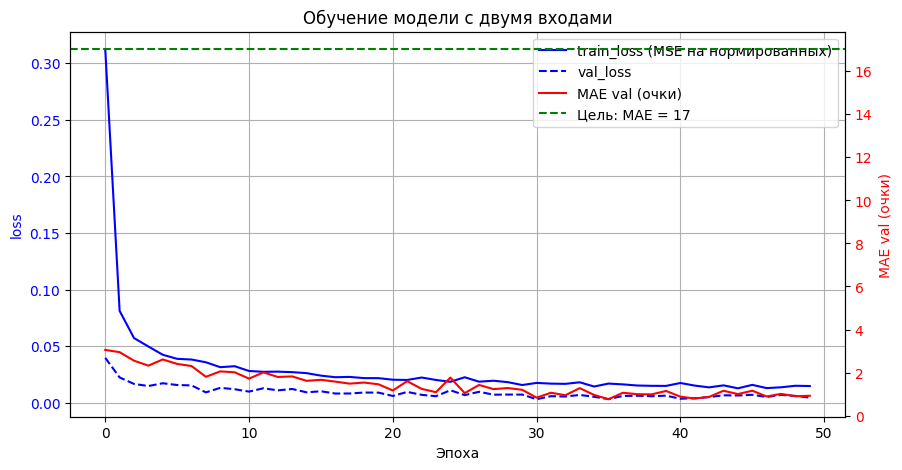

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(history.history['loss'],     'b-', label='train_loss (MSE на нормированных)')
ax1.plot(history.history['val_loss'], 'b--', label='val_loss')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('loss', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid()

ax2 = ax1.twinx()
ax2.plot(mae_pts_history, 'r-', label='MAE val (очки)')
ax2.axhline(17, color='g', linestyle='--', label='Цель: MAE = 17')
ax2.set_ylabel('MAE val (очки)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Объединяем легенды
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Обучение модели с двумя входами')
plt.show()


## 7. Финальная проверка — `check_MAE_predict1_DubbleInput`

Функция повторяет логику из шаблона: делает predict, считает MAE, печатает результат и рисует scatter «правильное vs предсказанное».

In [10]:
def check_MAE_predict1_DubbleInput(model, x_data, x_data_text,
                                   y_data_not_scaled, plot=False):
    pred_sc = model.predict([x_data, x_data_text], verbose=0)
    y_pred  = y_scaler.inverse_transform(pred_sc).ravel()

    mae = float(np.mean(np.abs(y_data_not_scaled - y_pred)))
    rel = mae / y_data_not_scaled.mean() * 100
    n   = len(y_data_not_scaled)
    print(f'Средняя абсолютная ошибка {mae:.3f} очков '
          f'это {rel:.3f}% от общей выборки в {n} игр')

    if plot:
        plt.figure(figsize=(7, 7))
        plt.scatter(y_data_not_scaled, y_pred, alpha=0.3, s=8)
        plt.xlabel('Правильные значения (очки)')
        plt.ylabel('Предсказания (очки)')
        plt.axis('equal')
        lim = (0, max(y_data_not_scaled.max(), y_pred.max()) + 10)
        plt.xlim(lim); plt.ylim(lim)
        plt.plot([0, lim[1]], [0, lim[1]], 'r--')
        plt.title(f'MAE = {mae:.2f} очков')
        plt.grid()
        plt.show()
    return mae


--- Валидация ---


Средняя абсолютная ошибка 0.844 очков это 0.558% от общей выборки в 7883 игр


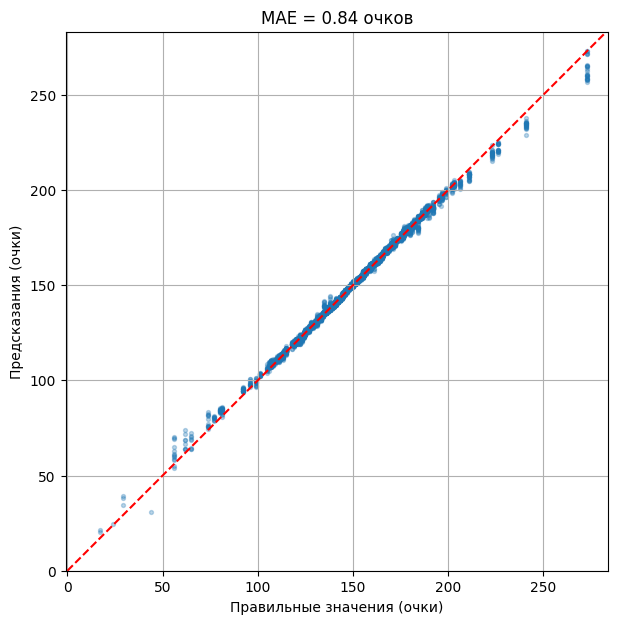


--- Train ---
Средняя абсолютная ошибка 0.829 очков это 0.546% от общей выборки в 44567 игр


In [11]:
# Финальная проверка на валидации
print('--- Валидация ---')
mae_val = check_MAE_predict1_DubbleInput(
    model, x_val_num, x_val_txt, y_val_orig, plot=True
)

# Контрольная проверка на train
print('\n--- Train ---')
mae_tr = check_MAE_predict1_DubbleInput(
    model, x_tr_num, x_tr_txt, y_tr_orig, plot=False
)
